# Chapter 4: Lotka-Volterra Model Validation
**Supplementary Code for Dissertation Figures 4.2 – 4.5**

This notebook validates both the non-spatial and spatial stochastic implementations of the Lotka-Volterra predator-prey model against their macroscopic limits. 

The validation is split into two phases:
1. **Non-Spatial Scaling (Figs 4.2 & 4.3):** Demonstrating the convergence of exact SSA and Chemical Langevin Equation (CLE) realisations towards the deterministic Runge-Kutta (RK4) solution as system volume ($\Omega$) increases.
2. **Spatial Dynamics (Figs 4.4 & 4.5):** Comparing the spatiotemporal evolution of the system across the discrete spatial SSA and the continuous spatial CLE approximations.

*Note: Custom deterministic solvers (e.g., RK4) are imported directly from the repository's `src.solvers` module to prevent numerical drift in the cyclic phase orbits.*

In [2]:
# Environment Setup & Module Imports
import sys
import os
import time
import jax
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jsmfsb

# Route imports to the src folder
sys.path.append(os.path.abspath('..'))

# Enable autoreload for custom modules
%load_ext autoreload
%autoreload 2

# Academic Plotting
sns.set_theme(style='ticks')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Non-Spatial Simulation Data Generation

def simulate_lv(omega, key, n_ssa=5, dt=0.05):
    """Generates an ensemble of SSA, CLE, and RK4 trajectories scaled by volume (Omega)."""
    lv_sh = f"""
    @model:3.1.1=LotkaVolterra
    @compartments
     Cell
    @species
     Cell:Prey={int(50 * omega)}
     Cell:Predator={int(100 * omega)}
    @reactions
     @r=PreyReproduction
      Prey -> 2Prey
      1.0*Prey
     @r=PredatorPreyInteraction
      Prey+Predator -> 2Predator
      {0.005 / omega}*Prey*Predator
     @r=PredatorDeath
      Predator ->
      0.6*Predator
    """
    mod = jsmfsb.shorthand_to_spn(lv_sh)

    # Multiple SSA
    keys = jax.random.split(key, n_ssa + 2)
    ssa_runs = [jsmfsb.sim_time_series(keys[k], mod.m, 0, 30, dt, mod.step_gillespie()) for k in range(n_ssa)]

    # Single CLE 
    cle_run = jsmfsb.sim_time_series(keys[n_ssa], mod.m, 0, 30, dt, mod.step_cle())

    # Deterministic RK4 (imported from src.solvers)
    ode_run = jsmfsb.sim_time_series(keys[n_ssa+1], mod.m, 0, 30, dt, step_rk4(mod))

    return ssa_runs, cle_run, ode_run

### Figure 4.2: Concentration Trajectories at Different System Volumes
A comparison of population dynamics highlighting how intrinsic noise dampens as the system volume ($\Omega$) increases. At $\Omega = 100$, the stochastic trajectories tightly bound the deterministic RK4 solution.

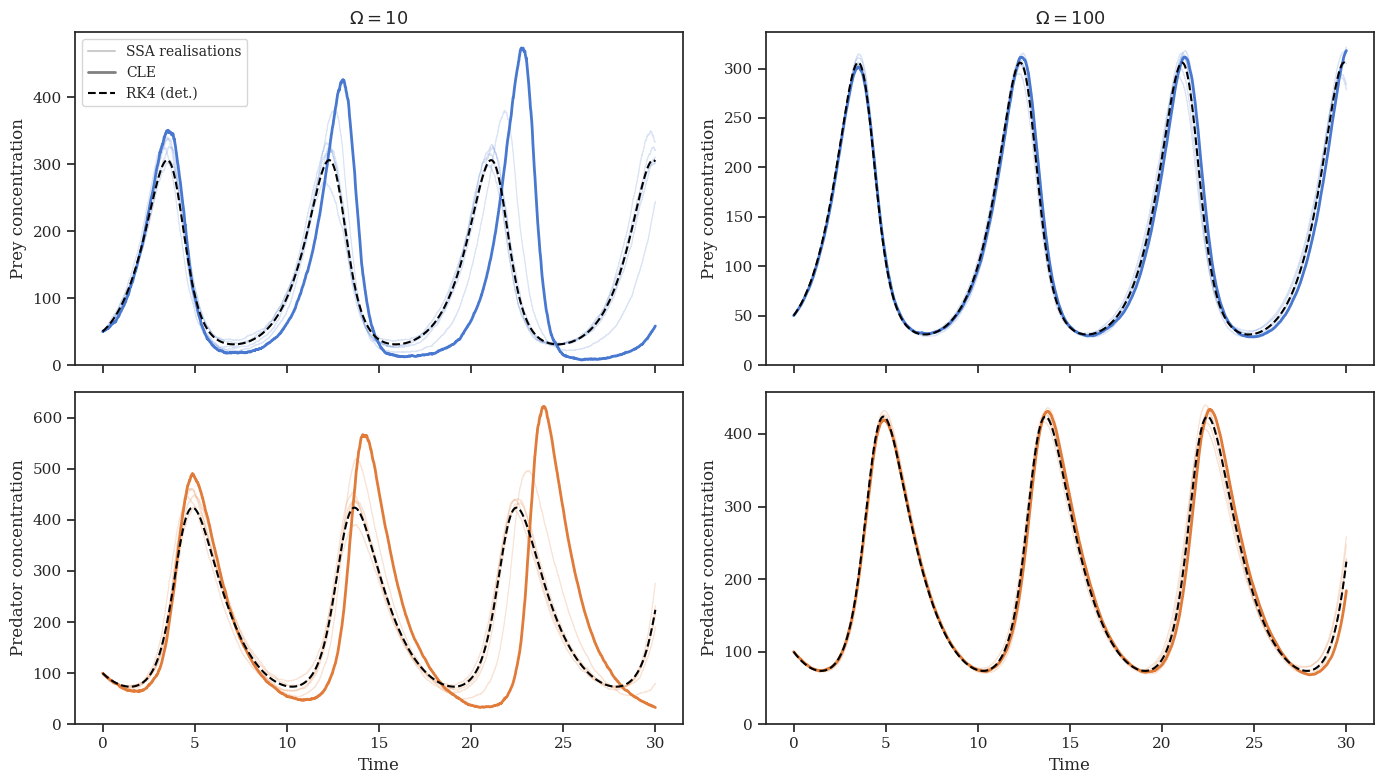

In [ ]:
# Figure 4.2 Execution

k0 = jax.random.key(42)
k1, k2 = jax.random.split(k0)

volumes  = [10, 100]
species  = ['Prey', 'Predator']
colours  = ['#4878CF', '#E07B39']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for col, (omega, key) in enumerate(zip(volumes, [k1, k2])):
    ssa_runs, cle_run, ode_run = simulate_lv(omega, key, dt=0.01)
    t = jnp.linspace(0, 30, ssa_runs[0].shape[0])

    for row, (sp, col_hex) in enumerate(zip(species, colours)):
        ax = axes[row, col]
        sp_idx = row

        # Faint SSA
        for run in ssa_runs:
            ax.step(t, run[:, sp_idx] / omega, color=col_hex,
                    alpha=0.2, linewidth=0.8, where='post')

        # CLE
        ax.plot(t, cle_run[:, sp_idx] / omega, color=col_hex,
                linewidth=2, label='CLE', zorder=3)

        # Deterministic RK4
        ax.plot(t, ode_run[:, sp_idx] / omega, color='black',
                linewidth=1.5, linestyle='--', label='RK4 (det.)', zorder=4)
                
        ax.set_ylim(bottom=0)
        ax.set_ylabel(f"{sp} concentration")
        if row == 0:
            ax.set_title(f"$\\Omega = {omega}$", fontweight='bold', fontsize=13)
        if row == 1:
            ax.set_xlabel("Time")

legend_elements = [
    Line2D([0], [0], color='grey', alpha=0.4, linewidth=1.5, label='SSA realisations'),
    Line2D([0], [0], color='grey', linewidth=2, label='CLE'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='RK4 (det.)'),
]
axes[0, 0].legend(handles=legend_elements, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('../Dissertation_Figures/Fig4_2_LV_Validation.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 4.3: Stochastic vs. Deterministic Phase Portrait
A state-space view of the Lotka-Volterra dynamics at $\Omega = 100$. The RK4 method maintains a closed limit cycle, while the exact SSA and CLE demonstrate the characteristic demographic stochasticity that causes real biological systems to deviate from perfect cyclic orbits.

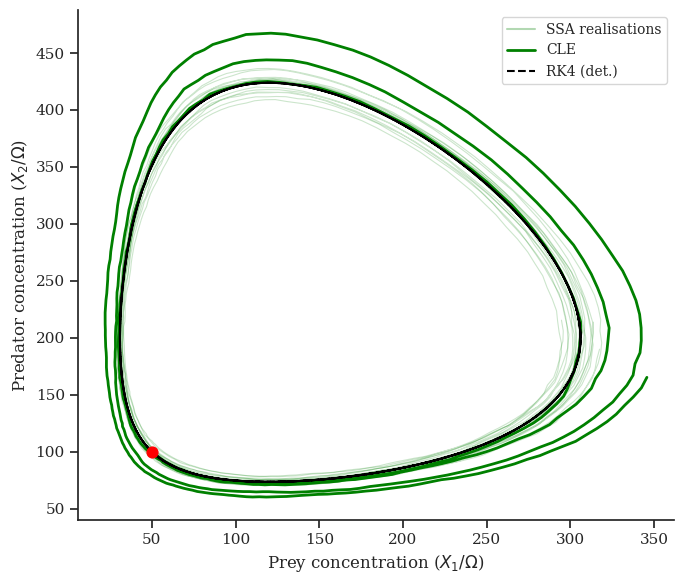

In [ ]:
# Figure 4.3 Execution

fig, ax = plt.subplots(figsize=(7, 6))

omega = 100
# Reusing the k1 key and simulation function
ssa_runs, cle_run, ode_run = simulate_lv(omega, k1)

# Faint SSA realisations
for run in ssa_runs:
    ax.plot(run[:, 0] / omega, run[:, 1] / omega,
            color='green', alpha=0.2, linewidth=0.8)

# Bold CLE
ax.plot(cle_run[:, 0] / omega, cle_run[:, 1] / omega,
        color='green', linewidth=2, label='CLE', zorder=3)

# Deterministic RK4
ax.plot(ode_run[:, 0] / omega, ode_run[:, 1] / omega,
        color='black', linewidth=1.5, linestyle='--',
        label='RK4 (det.)', zorder=4)

# Mark initial condition
ax.scatter([50], [100], color='red', zorder=5, s=60, label='Initial condition')

legend_elements_phase= [
    Line2D([0], [0], color='green', alpha=0.3, linewidth=1.5, label='SSA realisations'),
    Line2D([0], [0], color='green', linewidth=2, label='CLE'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='RK4 (det.)'),
]

ax.set_xlabel('Prey concentration ($X_1 / \\Omega$)')
ax.set_ylabel('Predator concentration ($X_2 / \\Omega$)')
ax.legend(handles=legend_elements_phase, frameon=True, fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig('../Dissertation_Figures/Fig4_3_LV_Phase_Portrait.png', dpi=300, bbox_inches='tight')
plt.show()

### Spatial Lotka-Volterra Dynamics
To validate the spatial approximation, we simulate a $20 \times 20$ grid over 12 time units. The system is initialised with a concentrated population in the centre of the grid to observe the outward diffusion and subsequent reaction-diffusion wave. 

*Note: To manage memory efficiently, the simulation only saves the state matrix at specific intervals rather than storing the entire spatiotemporal trajectory.*

In [7]:
# Spatial Simulation (20x20 Grid)

M = 20
N = 20
lv = jsmfsb.models.lv()
k0 = jax.random.key(42)
k1, k2 = jax.random.split(k0)
diff = jnp.array([0.6, 0.6])

# Initialise with a central "drop" of populations
x0 = jnp.zeros((2, M, N))
x0 = x0.at[:, int(M / 2), int(N / 2)].set(lv.m)

# Import the 2D step functions
step_ssa = lv.step_gillespie_2d(diff)
step_cle = lv.step_cle_2d(diff)

compute_timepoints = [0, 2, 4, 6, 7, 8, 9, 10, 11, 12]
plot_timepoints = [0, 6, 8, 10, 12] 
plot_indices = [compute_timepoints.index(t) for t in plot_timepoints]

# --- Run simulations ---
ssa_frames, cle_frames = [x0], [x0]
x_ssa, x_cle = x0, x0
keys_ssa = jax.random.split(k1, len(compute_timepoints))
keys_cle = jax.random.split(k2, len(compute_timepoints))

print("Executing spatial models. This will take a moment...")
for i in range(1, len(compute_timepoints)):
    dt = compute_timepoints[i] - compute_timepoints[i-1]
    print(f"Stepping t={compute_timepoints[i-1]} -> t={compute_timepoints[i]}...", flush=True)
    
    x_ssa = step_ssa(keys_ssa[i], x_ssa, compute_timepoints[i-1], dt)
    x_cle = step_cle(keys_cle[i], x_cle, compute_timepoints[i-1], dt)
    
    # Block until ready ensures accurate sequential execution for spatial JAX models
    x_ssa.block_until_ready()
    x_cle.block_until_ready()
    
    ssa_frames.append(x_ssa)
    cle_frames.append(x_cle)
    print(f"  SSA prey total: {float(x_ssa[0].sum()):.0f}  |  CLE prey total: {float(x_cle[0].sum()):.0f}", flush=True)

print("Simulation complete. Proceed to plotting.")

Executing spatial models. This will take a moment...
Stepping t=0 -> t=2...
  SSA prey total: 281  |  CLE prey total: 1725
Stepping t=2 -> t=4...
  SSA prey total: 1993  |  CLE prey total: 12321
Stepping t=4 -> t=6...
  SSA prey total: 14655  |  CLE prey total: 88634
Stepping t=6 -> t=7...
  SSA prey total: 39512  |  CLE prey total: 229225
Stepping t=7 -> t=8...
  SSA prey total: 101905  |  CLE prey total: 368702
Stepping t=8 -> t=9...
  SSA prey total: 116007  |  CLE prey total: 10179
Stepping t=9 -> t=10...
  SSA prey total: 99876  |  CLE prey total: 335
Stepping t=10 -> t=11...
  SSA prey total: 90306  |  CLE prey total: 297
Stepping t=11 -> t=12...
  SSA prey total: 48872  |  CLE prey total: 458
Simulation complete. Proceed to plotting.


### Figures 4.4 & 4.5: Spatiotemporal Evolution (Prey and Predator)
The following visualisations contrast the exact spatial SSA against the continuous spatial CLE. While the CLE captures the macroscopic diffusion wave accurately, the exact SSA exhibits heavier demographic noise at the wavefronts.

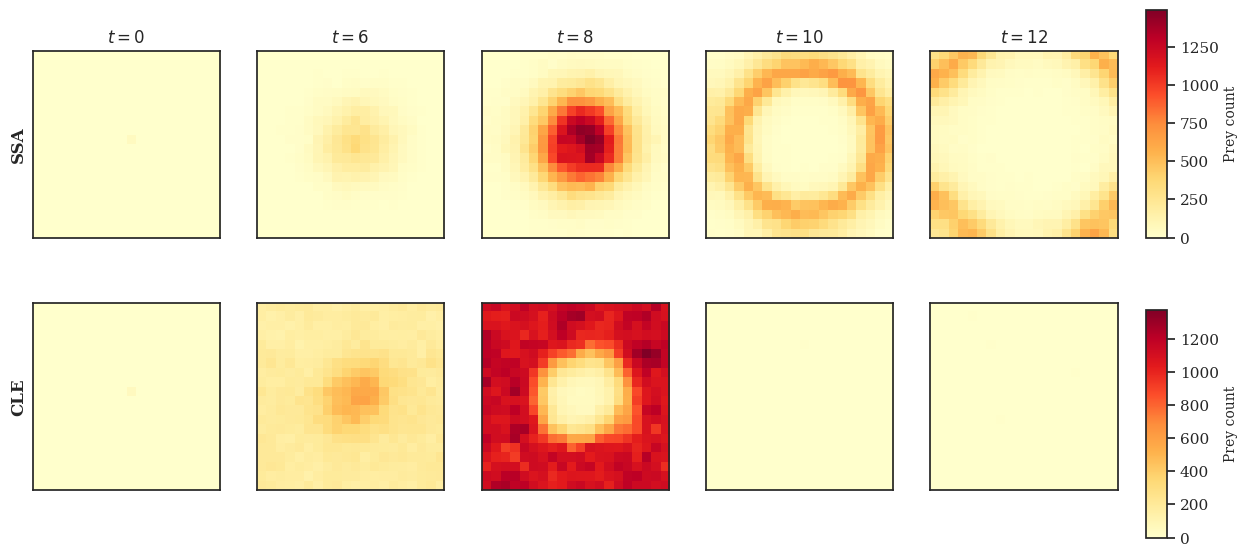

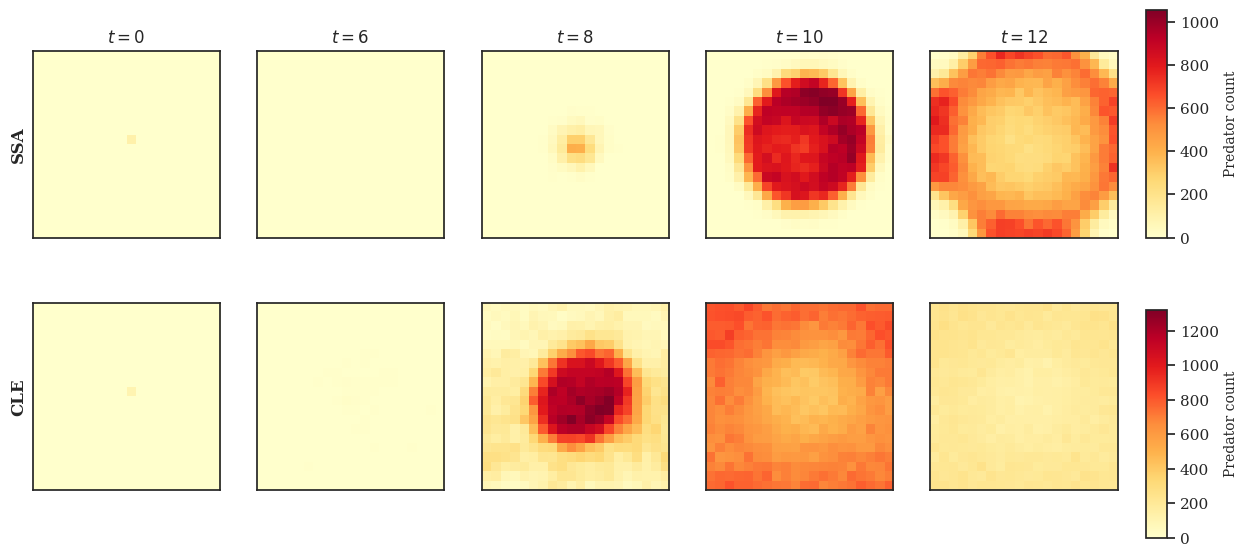

In [8]:
# Plotting Figures 4.4 and 4.5

for species_idx, species_label in enumerate(['Prey', 'Predator']):
    fig, axes = plt.subplots(2, len(plot_timepoints), figsize=(14, 6))
    plt.subplots_adjust(right=0.9)

    for row, (method, frames) in enumerate(zip(['SSA', 'CLE'], [ssa_frames, cle_frames])):
        
        # Calculate dynamic max scale for consistent colour mapping across the row
        row_vmax = max(float(frames[idx][species_idx].max()) for idx in plot_indices)

        for col, (idx, t) in enumerate(zip(plot_indices, plot_timepoints)):
            ax = axes[row, col]
            im = ax.imshow(frames[idx][species_idx], cmap='YlOrRd',
                           vmin=0, vmax=row_vmax, origin='lower')
            ax.set_xticks([])
            ax.set_yticks([])
            
            if row == 0:
                ax.set_title(f"$t = {t}$", fontsize=12)
            if col == 0:
                ax.set_ylabel(method, fontsize=12, fontweight='bold')

        # Add a dedicated colour bar for each method
        cbar_ax = fig.add_axes([0.92, 0.55 - row * 0.5, 0.015, 0.38])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label(f'{species_label} count', fontsize=10)

    # Save logic routing to the correct directory
    fig_num = "4_4" if species_label == 'Prey' else "4_5"
    save_path = f'../Dissertation_Figures/Fig{fig_num}_LV_spatial_{species_label.lower()}.png'
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()